In [1]:

import numpy as np
import matplotlib.pyplot as plt
from ModeloClassificado import fun_integrador, simular_2

In [ ]:


integrador, modelo = fun_integrador(dt=1)


y0 = [1713.946, 424.3868, 4454.146]
z0_vals = [
    7183839.554, 2991744.663, 7138588.549, 12043588.55,
    1.90714269, 14.13695208, 33.43556308, 2.911066071,
    30.52449701, 0.141369521, 281.8106616, 80.37817471
]

# Parâmetros ajustáveis
w_inj = 0.2
u1 = 1
GOR = 0.01
params = [w_inj, u1, GOR]

# Simulação
t0, tf, dt = 0, 18000, 1
t = np.arange(t0, tf, dt)

x_current = np.array(y0)
z_current = np.array(z0_vals)

results = simular_2(integrador, modelo, params, y0, z0_vals, t)


plt.figure(figsize=(15, 20))



plt.subplot(4, 2, 1)

plt.plot(t, results['Pwh']/1e5,  label=f'u1 = {u1}')
plt.title('Pressão na cabeça do poço')
plt.xlabel('Tempo /s')
plt.ylabel('Pwh / Bar')

plt.legend()

CasADi - 2025-11-09 18:26:01 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


Iniciando 100 simulações...
Simulação 1/100 — Estado: 0
Simulação 2/100 — Estado: 0
Simulação 3/100 — Estado: 0
Simulação 4/100 — Estado: 0
Simulação 5/100 — Estado: 0
Simulação 6/100 — Estado: 0
Simulação 7/100 — Estado: 0
Simulação 8/100 — Estado: 0
Simulação 9/100 — Estado: 0
Simulação 10/100 — Estado: 0
Simulação 11/100 — Estado: 0
Simulação 12/100 — Estado: 0
Simulação 13/100 — Estado: 0
Simulação 14/100 — Estado: 0
Simulação 15/100 — Estado: 0
Simulação 16/100 — Estado: 0
Simulação 17/100 — Estado: 0
Simulação 18/100 — Estado: 0
Simulação 19/100 — Estado: 0
Simulação 20/100 — Estado: 0
Simulação 21/100 — Estado: 0
Simulação 22/100 — Estado: 0
Simulação 23/100 — Estado: 0
Simulação 24/100 — Estado: 0
Simulação 25/100 — Estado: 0
Simulação 26/100 — Estado: 0
Simulação 27/100 — Estado: 0
Simulação 28/100 — Estado: 0
Simulação 29/100 — Estado: 0
Simulação 30/100 — Estado: 0
Simulação 31/100 — Estado: 0
Simulação 32/100 — Estado: 0
Simulação 33/100 — Estado: 0
Simulação 34/100 — Estad

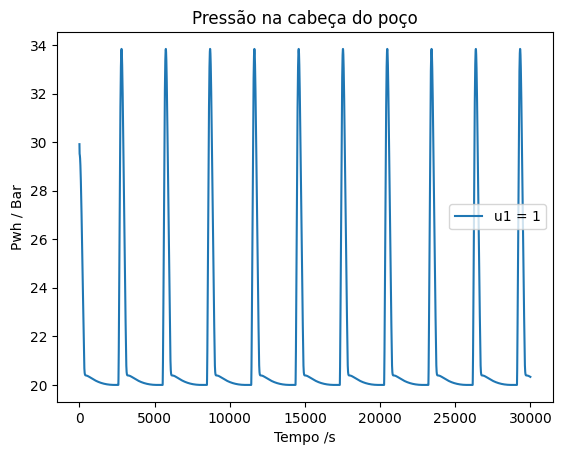

In [2]:
import numpy as np
import pandas as pd
import sys
from ModeloClassificado import fun_integrador, simular, run_simulation, simular_2



integrador, modelo = fun_integrador(dt=1)

y0 = [1713.946, 424.3868, 4454.146]
z0_vals = [
    7183839.554, 2991744.663, 7138588.549, 12043588.55,
    1.90714269, 14.13695208, 33.43556308, 2.911066071,
    30.52449701, 0.141369521, 281.8106616, 80.37817471
]

w_inj = 0.5
u1 = 1
GOR = 0.01

params = [w_inj,u1, GOR ]

t = np.arange(0, 30000, 1)

results = simular_2(integrador, modelo, params, y0, z0_vals, t)
plt.plot(t, results['Pwh']/1e5,  label=f'u1 = {u1}')
plt.title('Pressão na cabeça do poço')
plt.xlabel('Tempo /s')
plt.ylabel('Pwh / Bar')
plt.legend()

u1_values = np.linspace(0.1, 1.0, 10)
w_inj_values = np.linspace(0.2, 2.0, 10)
GOR_values = [0.01]


plt.legend()

all_results = []
count = 0
total = len(GOR_values) * len(u1_values) * len(w_inj_values)
print(f"Iniciando {total} simulações...")


for gor_val in GOR_values:
    for u1 in u1_values:
        for w_inj in w_inj_values:
            count += 1
            try:
                integrador, modelo = fun_integrador(dt=1)
                resultado = run_simulation(integrador, modelo, w_inj, u1, gor_val, y0, z0_vals, t)
                all_results.append(resultado)
                print(f"Simulação {count}/{total} — Estado: {resultado['estado']}")
            except Exception as e:
                print(f"⚠️ Err33o na simulação {count}/{total}: {e}")


df = pd.DataFrame(all_results)

df.to_csv("resultados_estabilidade.csv", sep=';', decimal=',', index=False)



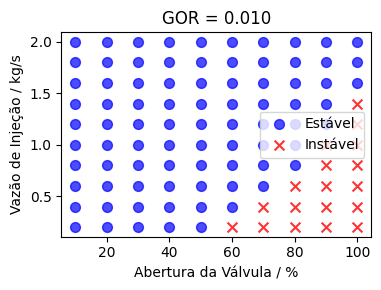

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Importa os resultados
df = pd.read_csv("resultados_estabilidade.csv", sep=';', decimal=',')

# Seleciona o valor de GOR (ajuste se quiser outro)
GOR_value = 0.01
df_gor = df[df['GOR'] == GOR_value]

# Cria o gráfico
plt.figure(figsize=(4, 3))

# Pontos estáveis (bolinhas azuis)
df_estavel = df_gor[df_gor['estado'] == '0']
plt.scatter(df_estavel['u1'] * 100, df_estavel['w_inj'], color='blue', s=50, alpha=0.7, label='Estável', marker='o')

# Pontos instáveis (X vermelhos)
df_instavel = df_gor[df_gor['estado'] == '1']
plt.scatter(df_instavel['u1'] * 100, df_instavel['w_inj'], color='red', s=50, alpha=0.8, label='Instável', marker='x')

# Rótulos e título
plt.xlabel('Abertura da Válvula / %')
plt.ylabel('Vazão de Injeção / kg/s')
plt.title(f'GOR = {GOR_value:.3f}')
plt.legend()
plt.grid(False)

# Deixa o estilo mais parecido com o seu
plt.xticks([20, 40, 60, 80, 100])
plt.tight_layout()
plt.show()
